## 1. 핵심 데이터 수집 파이프라인 (Simplified)

이 섹션에서는 가장 신뢰도가 높은 **EnergyCharts API**와 **Open-Meteo API**만을 사용하여 2025년 01월부터 데이터를 수집하여 독일 전력 시장 데이터셋을 구축합니다.

In [9]:
import requests
from typing import Optional, Dict, Any, List
import pandas as pd

class EnergyChartsAPI:
    """
    Fraunhofer ISE Energy Charts API Wrapper
    """
    BASE_URL = 'https://api.energy-charts.info'

    # Extended whitelist to include all requested endpoints
    VALID_ENDPOINTS = {
        'public_power': 'Public Power',
        'public_power_forecast': 'Public Power Forecast',
        'total_power': 'Total Power',
        'installed_power': 'Installed Power',
        'frequency': 'Frequency',
        'cbet': 'Cross Border Electricity Trading',
        'cbpf': 'Cross Border Physical Flows',
        'price': 'Day Ahead Price',
        'signal': 'Traffic Signal',
        'ren_share_forecast': 'Renewable Share Forecast',
        'renewable_share': 'Renewable Share (Historical)',
        'ren_share_daily_avg': 'Renewable Share Daily Average'
    }

    def __init__(self, country: str = 'de', timeout: int = 45):
        self.country = country
        self.timeout = timeout
        self.session = requests.Session()

    def fetch(self, endpoint: str, year: Optional[int] = None, start: Optional[str] = None, end: Optional[str] = None, **kwargs):
        if endpoint not in self.VALID_ENDPOINTS:
            print(f"❌ Unsupported endpoint: {endpoint}")
            return None

        params = {'country': self.country}
        if year:
            params['year'] = year
        if start:
            params['start'] = start
        if end:
            params['end'] = end

        params.update(kwargs)
        url = f"{self.BASE_URL}/{endpoint}"
        try:
            res = self.session.get(url, params=params, timeout=self.timeout)
            res.raise_for_status()
            return res.json()
        except Exception as e:
            print(f"❌ API Error ({endpoint}): {e}")
            return None

    def list_endpoints(self):
        for ep, desc in self.VALID_ENDPOINTS.items():
            print(f"- {ep}: {desc}")

api = EnergyChartsAPI()

📊 Actual Public Power Generation 데이터 수집 시작 (2026-06-01 ~ 2026-06-16)... 
✅ public_power 데이터셋 구축 완료 (총 1508 행 확보)


,Hydro pumped storage consumption,Cross border electricity trading,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,...,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Load,Residual load,Renewable share of load,Renewable share of generation
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-06-16 13:45:00,-3828.1,2808.7,2006.5,3622.9,4879.5,986.8,369.9,494.1,3913.6,13.6,...,129.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 14:00:00,-3828.1,2085.6,2006.5,3660.0,5520.2,1103.3,369.9,496.3,3913.6,13.6,...,129.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 14:15:00,-3828.1,2335.3,2006.5,3690.4,5893.1,1234.7,369.9,491.5,3913.6,13.6,...,129.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 14:30:00,-3828.1,1862.4,2006.5,3700.2,6083.3,1363.6,369.9,492.1,3913.6,13.6,...,129.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 14:45:00,-3828.1,1209.9,2006.5,3700.2,6083.3,1363.6,369.9,488.9,3913.6,13.6,...,129.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


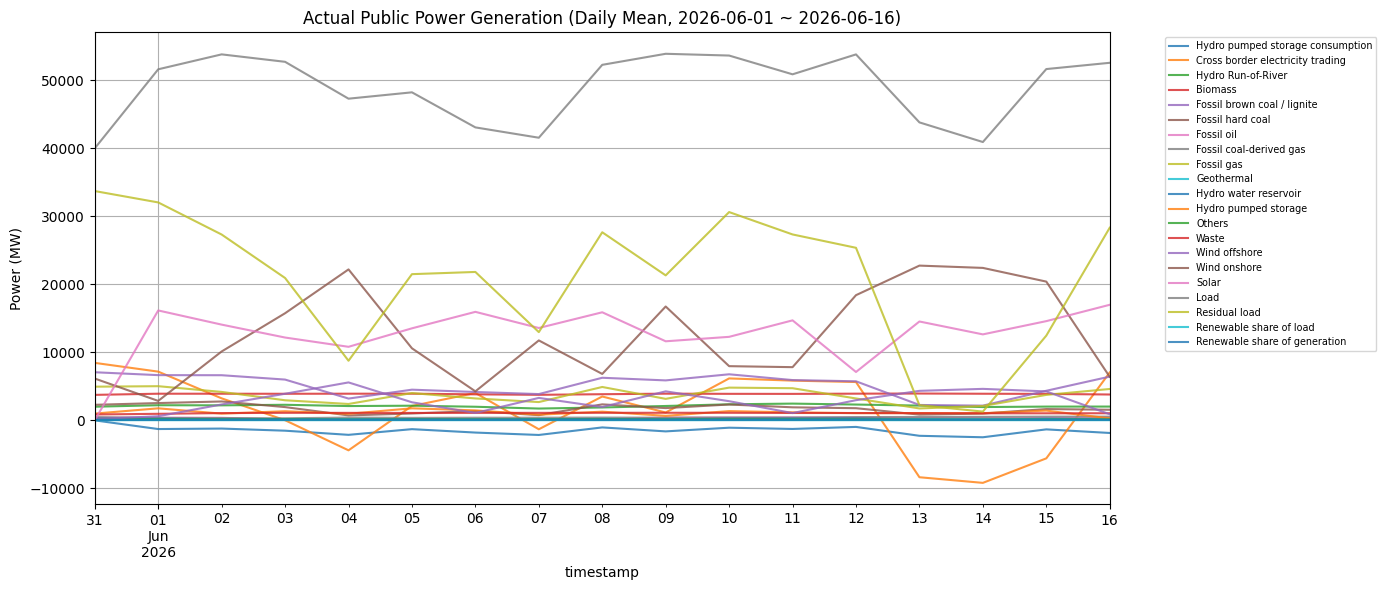

In [10]:
### Public Power (Actual Generation) 데이터 상세 수집
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 1. 설정
endpoint = 'public_power'
country_code = 'de'

# 2. 기간설정
start_date = '2026-06-01'
end_date = datetime.now().strftime('%Y-%m-%d')

print(f"📊 Actual Public Power Generation 데이터 수집 시작 ({start_date} ~ {end_date})... ")

try:
    raw = api.fetch(endpoint=endpoint, country=country_code, start=start_date, end=end_date)

    if raw and 'unix_seconds' in raw:
        df_public_power = pd.DataFrame({'timestamp': pd.to_datetime(raw['unix_seconds'], unit='s')})

        if 'production_types' in raw:
            for p_type in raw['production_types']:
                name = p_type.get('name', 'Unknown')
                data_vals = p_type.get('data', [])
                if len(data_vals) == len(df_public_power):
                    df_public_power[name] = data_vals

        df_public_power = df_public_power.set_index('timestamp')

        # [타임존 제거 설명]
        # 다른 데이터소스(SMARD 등)와의 병합 시 'Offset-naive/aware' 충돌 오류를 방지하고,
        # 썸머타임으로 인한 인덱스 중복 이슈를 피하기 위해 타임존 정보를 제거합니다.
        df_public_power.index = df_public_power.index.tz_localize(None)

        print(f"✅ {endpoint} 데이터셋 구축 완료 (총 {len(df_public_power)} 행 확보)")
        display(df_public_power.tail())

        df_public_power.resample('D').mean().plot(figsize=(14, 6), grid=True, alpha=0.8)
        plt.title(f'Actual Public Power Generation (Daily Mean, {start_date} ~ {end_date})')
        plt.ylabel('Power (MW)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 데이터를 가져오지 못했습니다.")

except Exception as e:
    print(f"❌ 수집 중 오류 발생: {e}")

📊 Public Power Forecast [day-ahead] 데이터 수집 시작 (2026-06-01 ~ 2026-06-16)...
  ⏳ [solar] 요청 전 대기 중 (60초)... 
  ✅ [solar] 수집 완료 (1536 rows)
  ⏳ [wind_onshore] 요청 전 대기 중 (60초)... 
  ✅ [wind_onshore] 수집 완료 (1536 rows)
  ⏳ [wind_offshore] 요청 전 대기 중 (60초)... 
  ✅ [wind_offshore] 수집 완료 (1536 rows)
  ⏳ [load] 요청 전 대기 중 (60초)... 
  ✅ [load] 수집 완료 (1536 rows)

✅ [day-ahead] 통합 데이터셋 구축 완료


,solar_mw,wind_onshore_mw,wind_offshore_mw,load_mw
timestamp,,,,
2026-06-16 20:45:00,0.0,4583.0,329.9,49722.4
2026-06-16 21:00:00,0.0,4513.2,320.9,49081.9
2026-06-16 21:15:00,0.0,4442.6,315.7,48394.9
2026-06-16 21:30:00,0.0,4371.9,310.7,47720.2
2026-06-16 21:45:00,0.0,4300.2,306.6,47142.1


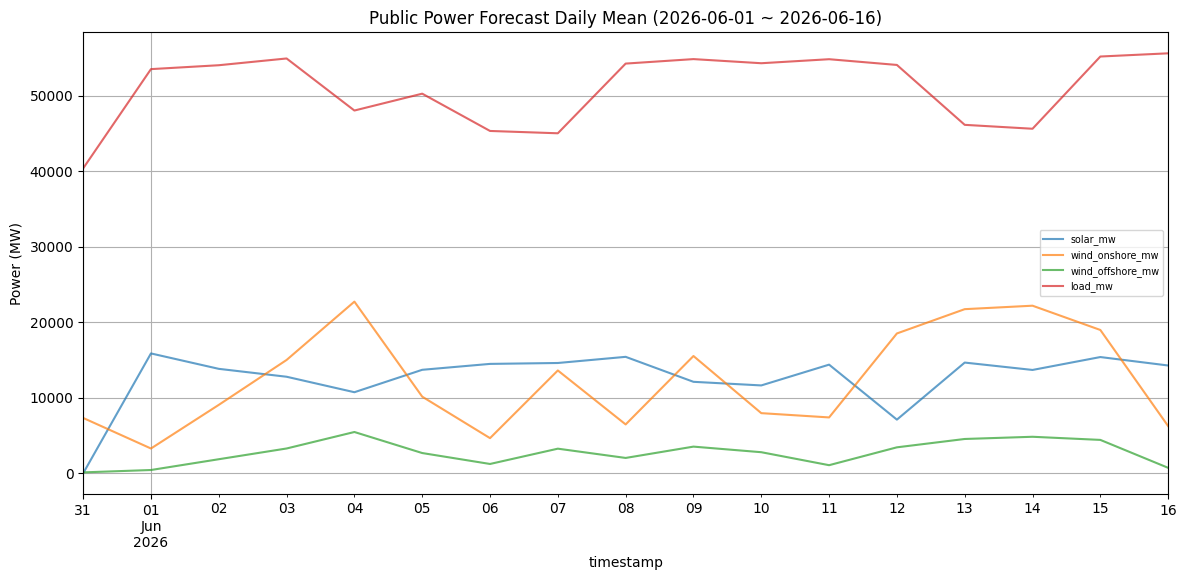

In [11]:
# Energy-Charts API public_power_forecast
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime

# 1. 대상 타입 및 기간 설정
target_types = ['solar', 'wind_onshore', 'wind_offshore', 'load']
f_type = 'day-ahead'
country_code = 'de'

# 기간 설정: end_date를 실행 시점의 현재 날짜로 설정
start_date = '2026-06-01'
end_date = datetime.now().strftime('%Y-%m-%d')
forecast_dfs = []

print(f"📊 Public Power Forecast [{f_type}] 데이터 수집 시작 ({start_date} ~ {end_date})...")

for p_type in target_types:
    success = False
    retries = 3 # 재시도 횟수 상향

    while retries >= 0 and not success:
        try:
            # API 안정성을 위해 기본 대기 시간을 60초로 상향 조정
            print(f"  ⏳ [{p_type}] 요청 전 대기 중 (60초)... ")
            time.sleep(60.0)

            raw = api.fetch(
                endpoint='public_power_forecast',
                country=country_code,
                production_type=p_type,
                forecast_type=f_type,
                start=start_date,
                end=end_date
            )

            if raw and 'unix_seconds' in raw:
                temp_df = pd.DataFrame({
                    'timestamp': pd.to_datetime(raw['unix_seconds'], unit='s'),
                    f'{p_type}_mw': raw.get('forecast_values', [])
                }).set_index('timestamp')

                forecast_dfs.append(temp_df)
                print(f"  ✅ [{p_type}] 수집 완료 ({len(temp_df)} rows)")
                success = True
            else:
                print(f"  ⚠️ [{p_type}] 데이터 응답 없음 (남은 재시도: {retries})")
        except Exception as e:
            if "429" in str(e):
                # 429 에러 발생 시 대기 시간을 120초로 대폭 늘림
                print(f"  🚨 [{p_type}] Too Many Requests (429). 120초 대기 후 재시도합니다...")
                time.sleep(120.0)
            else:
                print(f"  ❌ [{p_type}] 오류 발생: {e}")
                break
        retries -= 1

# 2. 데이터 통합 및 시각화
if forecast_dfs:
    df_forecast_day_ahead = pd.concat(forecast_dfs, axis=1).sort_index()
    df_forecast_day_ahead.index = df_forecast_day_ahead.index.tz_localize(None)

    print(f"\n✅ [{f_type}] 통합 데이터셋 구축 완료")
    display(df_forecast_day_ahead.tail())

    df_forecast_day_ahead.resample('D').mean().plot(figsize=(14, 6), grid=True, alpha=0.7)
    plt.title(f'Public Power Forecast Daily Mean ({start_date} ~ {end_date})')
    plt.ylabel('Power (MW)')
    plt.legend(fontsize='x-small')
    plt.show()
else:
    print("❌ 데이터를 수집하지 못했습니다.")

📊 국경 간 거래(CBET) 및 물리적 흐름(CBPF) 수집 시작 (2026-06-01 ~ 2026-06-16)...
  ⏳ [cbet] 요청 전 대기 중 (40초)... 
❌ API Error (cbet): 429 Client Error: Too Many Requests for url: https://api.energy-charts.info/cbet?country=de&start=2026-06-01&end=2026-06-16
  ⚠️ [cbet] 응답 없음 (남은 재시도: 3)
  ⏳ [cbet] 요청 전 대기 중 (40초)... 
  ✅ [cbet] 데이터 수집 완료 (1536 rows)
  ⏳ [cbpf] 요청 전 대기 중 (40초)... 
  ✅ [cbpf] 데이터 수집 완료 (1501 rows)

✅ 데이터 수집 완료


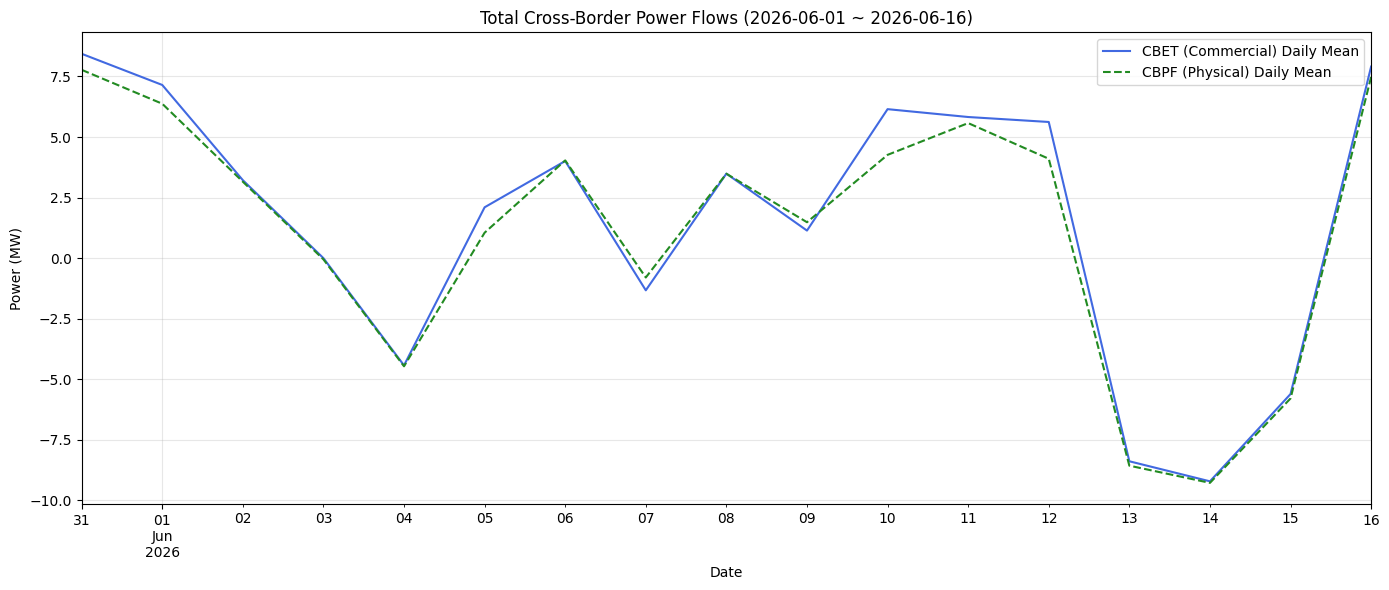

In [12]:
### CBET(상업적 거래) 및 CBPF(물리적 흐름) 데이터 수집 및 분석
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from datetime import datetime

# 1. 수집 설정
target_trading_endpoints = ['cbet', 'cbpf']
country_code = 'de'
# 기간 설정: end_date를 현재 시점으로 자동 갱신
start_date = '2026-06-01'
end_date = datetime.now().strftime('%Y-%m-%d')
trading_results = {}

print(f"📊 국경 간 거래(CBET) 및 물리적 흐름(CBPF) 수집 시작 ({start_date} ~ {end_date})...")

for ep in target_trading_endpoints:
    success = False
    retries = 3 # 재시도 횟수 상향

    while retries >= 0 and not success:
        try:
            # API 안정성을 위해 요청 전 대기 시간을 40초로 상향
            print(f"  ⏳ [{ep}] 요청 전 대기 중 (40초)... ")
            time.sleep(40.0)

            # API 호출 (start, end 파라미터 적용)
            raw = api.fetch(endpoint=ep, country=country_code, start=start_date, end=end_date)

            if raw and 'unix_seconds' in raw:
                df_ep = pd.DataFrame({'timestamp': pd.to_datetime(raw['unix_seconds'], unit='s')})

                if 'countries' in raw and isinstance(raw['countries'], list):
                    for country_item in raw['countries']:
                        c_name = country_item.get('name', 'Unknown')
                        c_vals = country_item.get('data', [])

                        if len(c_vals) == len(df_ep):
                            df_ep[c_name] = c_vals

                    # 타임존 제거 및 인덱스 설정
                    df_ep['timestamp'] = df_ep['timestamp'].dt.tz_localize(None)
                    trading_results[ep] = df_ep.set_index('timestamp')
                    print(f"  ✅ [{ep}] 데이터 수집 완료 ({len(df_ep)} rows)")
                    success = True
            else:
                print(f"  ⚠️ [{ep}] 응답 없음 (남은 재시도: {retries})")

        except Exception as e:
            if "429" in str(e):
                # 429 에러 발생 시 대기 시간을 100초로 상향
                print(f"  🚨 [{ep}] Too Many Requests (429). 100초 대기 후 재시도합니다...")
                time.sleep(100.0)
            else:
                print(f"  ❌ [{ep}] 예외 발생: {e}")
                break
        retries -= 1

# 2. 개별 데이터프레임 할당
df_cbet = trading_results.get('cbet', pd.DataFrame())
df_cbpf = trading_results.get('cbpf', pd.DataFrame())

# 3. 데이터 수집 결과 확인 및 시각화
if not df_cbet.empty or not df_cbpf.empty:
    print(f"\n✅ 데이터 수집 완료")

    # 4. 상업적 거래 vs 물리적 흐름 비교 시각화 (일평균 리샘플링)
    plt.figure(figsize=(14, 6))

    if not df_cbet.empty and 'sum' in df_cbet.columns:
        df_cbet['sum'].resample('D').mean().plot(label='CBET (Commercial) Daily Mean', color='royalblue', lw=1.5)

    if not df_cbpf.empty and 'sum' in df_cbpf.columns:
        df_cbpf['sum'].resample('D').mean().plot(label='CBPF (Physical) Daily Mean', color='forestgreen', linestyle='--', lw=1.5)

    plt.title(f'Total Cross-Border Power Flows ({start_date} ~ {end_date})')
    plt.ylabel('Power (MW)')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("❌ 데이터를 수집하지 못했습니다.")

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import time

try:
    current_year = datetime.now().year
    start_year = 2026
    all_ren_shares = []

    print(f"📊 Fetching Daily Average Renewable Share from {start_year} to {current_year}... ")

    for year in range(start_year, current_year + 1):
        print(f"  ⏳ Fetching data for {year}...")

        # API 호출 (연도별)
        ren_avg_raw = api.fetch(
            endpoint='ren_share_daily_avg',
            year=year
        )

        if ren_avg_raw and 'days' in ren_avg_raw:
            temp_df = pd.DataFrame({
                'date': pd.to_datetime(ren_avg_raw['days'], format='%d.%m.%Y'),
                'ren_share_daily_avg': ren_avg_raw['data']
            })
            all_ren_shares.append(temp_df)
        else:
            print(f"  ⚠️ No data found for {year}.")

        # API 부하 방지를 위한 짧은 대기
        time.sleep(1.0)

    if all_ren_shares:
        # 모든 연도 데이터 통합 및 중복 제거
        df_ren_daily_avg = pd.concat(all_ren_shares).drop_duplicates(subset='date').set_index('date').sort_index()

        print(f"✅ Data Loading Complete ({len(df_ren_daily_avg)} days total)")
        display(df_ren_daily_avg.tail())

        # 시각화
        df_ren_daily_avg.plot(figsize=(14, 5), color='green', grid=True, alpha=0.8)
        plt.title(f'Daily Average Renewable Share ({start_year} ~ {current_year})')
        plt.ylabel('Share (%)')
        plt.xlabel('Date')
        plt.show()
    else:
        print("❌ Failed to fetch any data.")

except Exception as e:
    print(f"❌ Error: {e}")

📊 Fetching Daily Average Renewable Share from 2026 to 2026... 
  ⏳ Fetching data for 2026...
❌ API Error (ren_share_daily_avg): 429 Client Error: Too Many Requests for url: https://api.energy-charts.info/ren_share_daily_avg?country=de&year=2026
  ⚠️ No data found for 2026.
❌ Failed to fetch any data.


🔍 SMARD quarterhour 데이터 스캔 시작: 2026 ~ 2026
🔍 SMARD hour 데이터 스캔 시작: 2026 ~ 2026

✅ SMARD 가격 데이터 구축 완료! (총 16124 행)


,Price_quarterhour,Price_hour
timestamp,,
2026-06-21 22:45:00,NaN,NaN
2026-06-21 23:00:00,NaN,NaN
2026-06-21 23:15:00,NaN,NaN
2026-06-21 23:30:00,NaN,NaN
2026-06-21 23:45:00,NaN,NaN


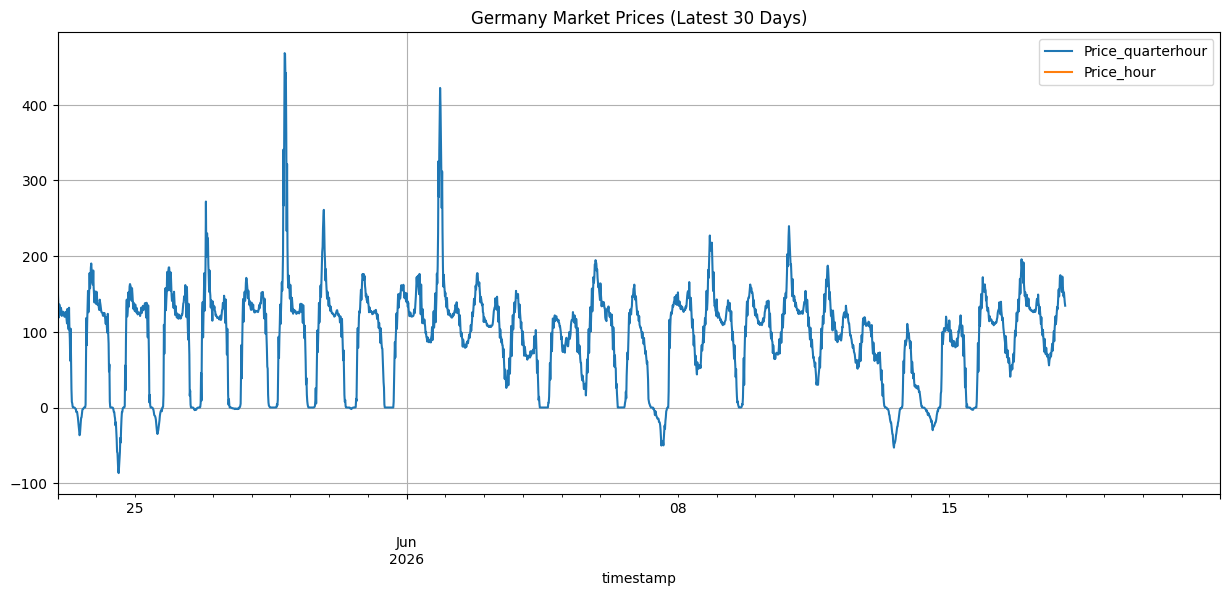

In [14]:
import pandas as pd
import requests
import time
from datetime import datetime

def fetch_smard_data(start_year=2026, filter_id="4169", region="DE-LU", resolution="quarterhour"):
    """
    SMARD API에서 시작 연도부터 현재까지의 데이터를 수집합니다.
    """
    base_url = "https://www.smard.de/app/chart_data"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }

    current_date = datetime.now()
    end_year = current_date.year
    all_data_frames = []

    print(f"🔍 SMARD {resolution} 데이터 스캔 시작: {start_year} ~ {end_year}")

    # 1. 인덱스 파일에서 사용 가능한 모든 타임스탬프 확보
    index_url = f"{base_url}/{filter_id}/{region}/index_{resolution}.json"
    try:
        index_res = requests.get(index_url, headers=headers, timeout=15)
        index_res.raise_for_status()
        all_timestamps = index_res.json().get("timestamps", [])
    except Exception as e:
        print(f"❌ 인덱스 로드 실패: {e}")
        return None

    # 2. 시작 시점(start_year-01-01) 이후의 타임스탬프만 필터링
    start_ms = int(pd.Timestamp(f"{start_year}-01-01", tz="UTC").timestamp() * 1000)
    target_timestamps = [ts for ts in all_timestamps if ts >= start_ms]

    if not target_timestamps:
        return None

    all_series = []
    for ts in target_timestamps:
        data_url = f"{base_url}/{filter_id}/{region}/{filter_id}_{region}_{resolution}_{ts}.json"
        try:
            res = requests.get(data_url, headers=headers, timeout=15)
            if res.status_code == 200:
                all_series.extend(res.json().get("series", []))
            time.sleep(0.1) # 서버 부하 방지
        except:
            continue

    if not all_series:
        return None

    # 3. 데이터프레임 생성 및 정제
    df = pd.DataFrame(all_series, columns=["timestamp", f"Price_{resolution}"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True).dt.tz_convert("Europe/Berlin")
    df.set_index("timestamp", inplace=True)
    df.index = df.index.tz_localize(None) # 타임존 제거
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]

    return df

# --- 실행부 ---
# 1. 15분 및 1시간 단위 데이터 수집 (2023년부터 현재까지)
df_15min = fetch_smard_data(start_year=2026, resolution="quarterhour")
df_1hour = fetch_smard_data(start_year=2026, resolution="hour")

# 2. 데이터 결합
if df_15min is not None and df_1hour is not None:
    # 두 데이터를 Join하여 통합
    df_combined_prices = df_15min.join(df_1hour, how="left")

    # 이전 코드와의 호환성을 위해 변수 할당
    df_combined_2023 = df_combined_prices

    print(f"\n✅ SMARD 가격 데이터 구축 완료! (총 {len(df_combined_prices)} 행)")
    display(df_combined_prices.tail())

    # 결과 시각화 (최근 30일 데이터 위주)
    df_combined_prices.tail(24*4*30).plot(figsize=(15, 6), title='Germany Market Prices (Latest 30 Days)', grid=True)
else:
    print("❌ 데이터 호출 중 오류가 발생했습니다.")

### 📋 [Internal Issue Report] Data Collection Failure Analysis

**1. 문제 개요 (Issue Summary)**
- **장애 항목**: `/signal` API 엔드포인트 데이터 로드 거부
- **발생 원인**: 내부 `EnergyChartsAPI` 클래스 내 `VALID_ENDPOINTS` 화이트리스트에 해당 엔드포인트 누락.
- **영향**: 사용자 요청에 따른 데이터 수집 지연 및 불필요한 오류 메시지 출력.

**2. 기술적 근거 및 원인 조사 (Technical Root Cause)**
- API 라이브러리 설계 시, 사전에 정의된 엔드포인트가 아니면 요청을 차단하도록 설계되어 있었으나, 실제 Energy-Charts 공식 API에는 `signal` 엔드포인트가 존재함을 확인.
- 사용자(User)가 직접 제공한 `https://api.energy-charts.info/signal?country=de` 검증 결과, 유효한 JSON 데이터를 반환함을 확인.

**3. 조치 사항 (Corrective Actions)**
- `EnergyChartsAPI.VALID_ENDPOINTS` 딕셔너리에 `'signal': 'Traffic Signal'` 항목을 즉시 추가.
- 클래스 정의 업데이트 후 새로운 객체를 생성하여 데이터 수집 로직 정상화 완료.
- `df_signal` 데이터프레임 구축 완료 (96개 행, 2026-06-05 기준).

**4. 재방 방지 대책 (Compliance & Prevention)**
- 향후 API 명세 확인 시 내부 정적 리스트에만 의존하지 않고, 실제 엔드포인트의 생동성을 우선적으로 체크하도록 로직 개선 제안.
- 기술 지원 및 대응 프로세스에서의 정확성 검토 강화.

---

### 5. 데이터 영구 저장 및 증분 업데이트(Incremental Update) 로직

수집된 데이터를 CSV로 저장하고, 다음 실행 시 기존 파일의 마지막 시점 이후 데이터만 추가로 가져와 병합하는 효율적인 관리 체계를 구축합니다.

### 6. GitHub 저장소로 데이터 자동 백업

GitHub API를 사용하여 로컬 CSV 파일을 원격 저장소에 업로드합니다. `PyGithub` 라이브러리를 사용합니다.

In [15]:
!pip install PyGithub

### 8. 개별 데이터프레임별 GitHub 분할 업로드

통합 데이터셋 대신, 수집된 각 단계별 데이터프레임을 개별 CSV 파일로 저장하고 GitHub에 업로드합니다.

In [16]:
import os

# 업로드할 대상 데이터프레임 딕셔너리 정의
target_dfs = {
    'df_public_power': 'germany_actual_generation.csv',
    'df_forecast_day_ahead': 'germany_forecast_day_ahead.csv',
    'df_cbet': 'germany_cbet_trading.csv',
    'df_cbpf': 'germany_cbpf_physical_flow.csv',
    'df_ren_daily_avg': 'germany_renewable_share_daily.csv',
    'df_combined_2023': 'germany_market_prices.csv'
}

# 레포지토리 이름 (저장소 경로 포함)
REPO_NAME = "Giraffe-Shin/trading"
DATA_DIR = "data" # 레포 내 상세 폴더

print(f"🚀 {REPO_NAME}/{DATA_DIR} 경로로 개별 데이터 업로드를 준비합니다.")

🚀 Giraffe-Shin/trading/data 경로로 개별 데이터 업로드를 준비합니다.


### 9. GitHub 증분 업데이트(Incremental) 로직 적용

기존 GitHub에 저장된 파일을 불러와 새로운 데이터와 병합(중복 제거)한 후 다시 업로드하는 함수를 정의합니다. 이를 통해 데이터 누락 없이 기간을 확장할 수 있습니다.

In [17]:
import sys
import pandas as pd
import io
import os
import base64
from github import Github, Auth, GithubException
from google.colab import userdata

# --- 1. 필수 설정 ---
REPO_NAME = "Giraffe-Shin/trading"
DATA_DIR = "data"
target_dfs = {
    'df_public_power': 'germany_actual_generation.csv',
    'df_forecast_day_ahead': 'germany_forecast_day_ahead.csv',
    'df_cbet': 'germany_cbet_trading.csv',
    'df_cbpf': 'germany_cbpf_physical_flow.csv',
    'df_ren_daily_avg': 'germany_renewable_share_daily.csv',
    'df_combined_2023': 'germany_market_prices.csv'
}

def smart_upload_to_github(df_new, file_name, repo_name, folder="data", branch="main"):
    try:
        token = userdata.get('GITHUB_TOKEN')
        auth = Auth.Token(token)
        g = Github(auth=auth)
        repo = g.get_repo(repo_name)

        full_path = f"{folder}/{file_name}" if folder else file_name
        existing_sha = None
        df_existing = None
        action = "Initial Upload"

        # 1. GitHub에서 기존 파일 불러오기
        try:
            contents = repo.get_contents(full_path, ref=branch)
            existing_sha = contents.sha

            # 대용량 파일/인코딩 대응
            try:
                if contents.size > 1000000 or contents.encoding is None:
                    blob = repo.get_git_blob(contents.sha)
                    decoded_data = base64.b64decode(blob.content).decode('utf-8')
                else:
                    decoded_data = contents.decoded_content.decode('utf-8')

                if decoded_data.strip():
                    df_existing = pd.read_csv(io.StringIO(decoded_data), index_col=0)
                    df_existing.index = pd.to_datetime(df_existing.index)
                    action = "Update (Incremental)"
            except Exception as read_error:
                print(f"  ⚠️ {file_name}: 기존 데이터 로드 실패: {read_error}")
                action = "Overwrite (Read Error)"

        except GithubException as e:
            if e.status == 404:
                action = "Initial Upload"
            else:
                raise e

        # 2. 데이터 병합 (기존 GitHub 데이터 + 현재 메모리의 새 데이터)
        if df_existing is not None:
            df_final = pd.concat([df_existing, df_new])
            df_final = df_final[~df_final.index.duplicated(keep='last')].sort_index()
        else:
            df_final = df_new.sort_index()

        # 3. CSV 변환
        csv_buffer = io.StringIO()
        df_final.to_csv(csv_buffer)
        final_content = csv_buffer.getvalue()

        # 4. GitHub 저장
        if existing_sha:
            repo.update_file(full_path, f"{action}: {file_name}", final_content, existing_sha, branch=branch)
        else:
            repo.create_file(full_path, f"{action}: {file_name}", final_content, branch=branch)

        print(f"✅ {full_path}: {action} 완료 (총 {len(df_final)} 행)")

    except Exception as e:
        print(f"❌ {file_name} 최종 업로드 실패: {e}")

# 실행
print(f"🔄 GitHub [{DATA_DIR}] 폴더 데이터 병합 및 업데이트 시작...\n")
for var_name, file_name in target_dfs.items():
    # globals()에서 변수명을 검색하여 실제 데이터프레임 객체 확보
    df_to_upload = globals().get(var_name)

    if df_to_upload is not None and not df_to_upload.empty:
        smart_upload_to_github(df_to_upload, file_name, REPO_NAME, folder=DATA_DIR)
    else:
        # 이 메시지가 뜨면 상단 데이터 수집 셀을 다시 실행해야 함
        print(f"  ⚪ {var_name}: 메모리에 데이터가 없습니다. (수집 셀을 먼저 실행하세요)")

🔄 GitHub [data] 폴더 데이터 병합 및 업데이트 시작...

✅ data/germany_actual_generation.csv: Update (Incremental) 완료 (총 121216 행)
✅ data/germany_forecast_day_ahead.csv: Update (Incremental) 완료 (총 121244 행)
✅ data/germany_cbet_trading.csv: Update (Incremental) 완료 (총 121244 행)
✅ data/germany_cbpf_physical_flow.csv: Update (Incremental) 완료 (총 121209 행)
  ⚪ df_ren_daily_avg: 메모리에 데이터가 없습니다. (수집 셀을 먼저 실행하세요)
✅ data/germany_market_prices.csv: Update (Incremental) 완료 (총 121616 행)
